# W tej części zajmujemy się załadowaniem i przetworzeniem danych do postaci użytecznej, następnie przeprowadzamy wstępne EDA #


## 1. Konfiguracja Środowiska i Import Bibliotek ##

W celu przeprowadzenia analizy ilościowej, wykorzystujemy zestaw bibliotek dedykowanych do obliczeń naukowych, statystyki oraz wizualizacji danych finansowych.

### Stos Technologiczny:

*   **Przetwarzanie Danych:**
    *   `pandas`: Zarządzanie strukturami danych typu DataFrame, obsługa szeregów czasowych.
    *   `numpy`: Operacje wektorowe i funkcje matematyczne (np. logarytmowanie).
*   **Wizualizacja:**
    *   `matplotlib` & `seaborn`: Tworzenie technicznych wykresów cen, wolumenu oraz rozkładów statystycznych.
*   **Ekonometria i Statystyka:**
    *   `statsmodels.tsa`: Biblioteka do analizy szeregów czasowych (Testy stacjonarności ADF, analiza autokorelacji ACF/PACF).
    *   `scipy.stats`: Weryfikacja hipotez statystycznych, w tym testy normalności rozkładu (Jarque-Bera).
*   **Integracja Projektu:**
    *   `sys` & `os`: Konfiguracja ścieżek systemowych umożliwiająca importowanie autorskich modułów z katalogu `src/`.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Narzędzia statystyczne
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import stats

# Dodanie folderu src do ścieżki (wyjście z notebooks/ do głównego katalogu)
sys.path.append(os.path.abspath('../'))
from src.data_loader import load_data, clean_financial_data, analyze_data_content

# Ustawienia estetyczne wykresów
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['figure.dpi'] = 100

## 2. Wczytywanie i czyszczenie danych ##

Ładowanie danych

In [2]:
from pathlib import Path

# To znajdzie główny folder projektu (BICC_2026), 
# idąc od miejsca, gdzie jest ten notebook o dwa poziomy w górę
BASE_DIR = Path(os.getcwd()).parent
path = BASE_DIR / "data" / "raw" / "sp500_testowo.csv"

print(f"Szukam pliku w: {path.absolute()}")

if path.exists():
    df = load_data(str(path))
    print("Załadowano dane")
else:
    print("Pliku nadal nie ma. Wyświetlam zawartość folderu data/raw, żeby sprawdzić nazwę:")
    raw_dir = BASE_DIR / "data" / "raw"
    if raw_dir.exists():
        print(os.listdir(raw_dir))
    else:
        print(f"Folder {raw_dir} w ogóle nie istnieje!")

Szukam pliku w: c:\BICC_2026\data\raw\sp500_testowo.csv
✅ Ustawiono indeks czasowy na kolumnie: Date
Załadowano dane


Czyszczenie i analiza zawartości danych

In [3]:

df = clean_financial_data(df)
analyze_data_content(df)


📊 RAPORT ZAWARTOŚCI DANYCH
Liczba wierszy: 834
Liczba kolumn: 5

--- BRAKI W DANYCH ---
Brak brakujących danych.

--- TYPY I ZAKRESY ---
              Typ        Min        Max  Unique
Price     float64  3808.1000  7173.9100     833
Open      float64  3823.3700  7161.7500     834
High      float64  3839.7400  7178.7400     832
Low       float64  3794.3300  7146.7200     830
Change %  float64    -0.0597     0.0952     313

Zakres czasowy: 2023-01-03 00:00:00 do 2026-04-30 00:00:00
Częstotliwość danych: None



## 3. Wstępna analiza i wizualizacja danych ##

### Dodanie logarytmicznych stop zwrotu - to tez nas moze interesowac ###

In [4]:
# Obliczamy log-zwroty
df['returns'] = np.log(df['Price'] / df['Price'].shift(1))


# Usuwamy pierwszy wiersz (NaN po shift)
df = df.dropna()

### Wykresy cen i stop zwrotu ###

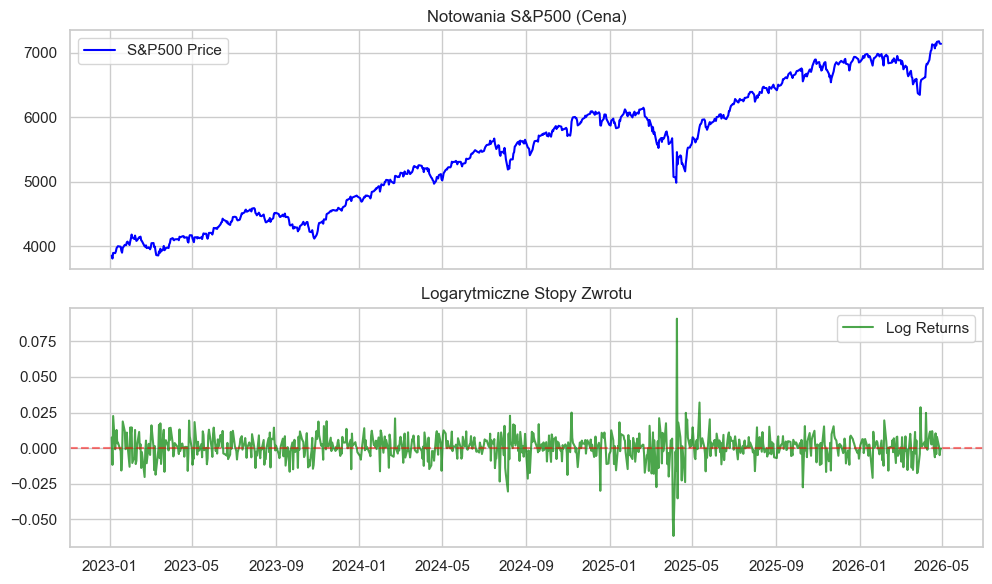

In [5]:
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Wykres ceny
ax[0].plot(df.index, df['Price'], color='blue', label='S&P500 Price')
ax[0].set_title('Notowania S&P500 (Cena)')
ax[0].legend()

# Wykres stóp zwrotu
ax[1].plot(df.index, df['returns'], color='green', label='Log Returns', alpha=0.7)
ax[1].axhline(0, color='red', linestyle='--', alpha=0.5)
ax[1].set_title('Logarytmiczne Stopy Zwrotu')
ax[1].legend()

plt.tight_layout()
plt.show()

### Dodatkowy wykres dla kwadratow stop zwrotu ###

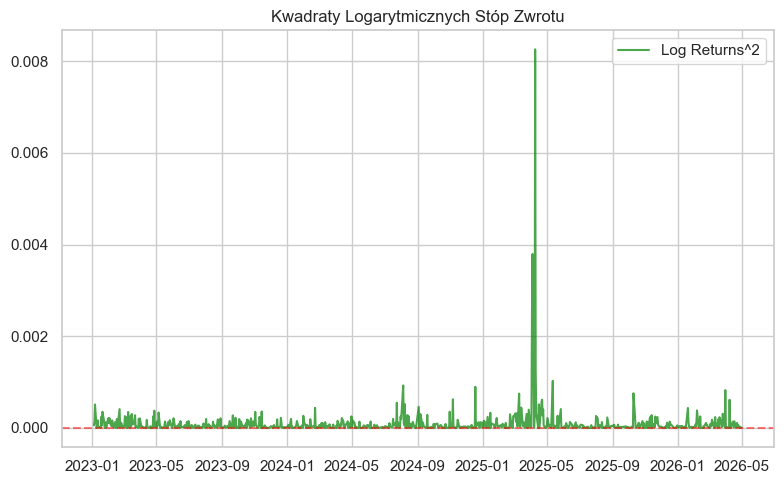

In [8]:
# Wykres kwadratów stóp zwrotu
fig, ax = plt.subplots(figsize=(8, 5))

plt.plot(df.index, df['returns']**2, color='green', label='Log Returns^2', alpha=0.7)
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.title('Kwadraty Logarytmicznych Stóp Zwrotu')
plt.legend()

plt.tight_layout()
plt.show()

### Test ADF na stacjonarność szeregu ###

In [9]:

def check_adfuller(series):
    result = adfuller(series.dropna())
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    if result[1] <= 0.05:
        print("✅ Szereg jest stacjonarny (odrzucamy hipotezę zerową)")
    else:
        print("❌ Szereg nie jest stacjonarny (brak stacjonarności)")

print("Test ADF dla Ceny:")
check_adfuller(df['Price'])
print("\nTest ADF dla Stóp Zwrotu:")
check_adfuller(df['returns'])

Test ADF dla Ceny:
ADF Statistic: -0.5228
p-value: 0.8875
❌ Szereg nie jest stacjonarny (brak stacjonarności)

Test ADF dla Stóp Zwrotu:
ADF Statistic: -16.1765
p-value: 0.0000
✅ Szereg jest stacjonarny (odrzucamy hipotezę zerową)


### Analiza autokorelacji i cząstkowej autokorelacji ###


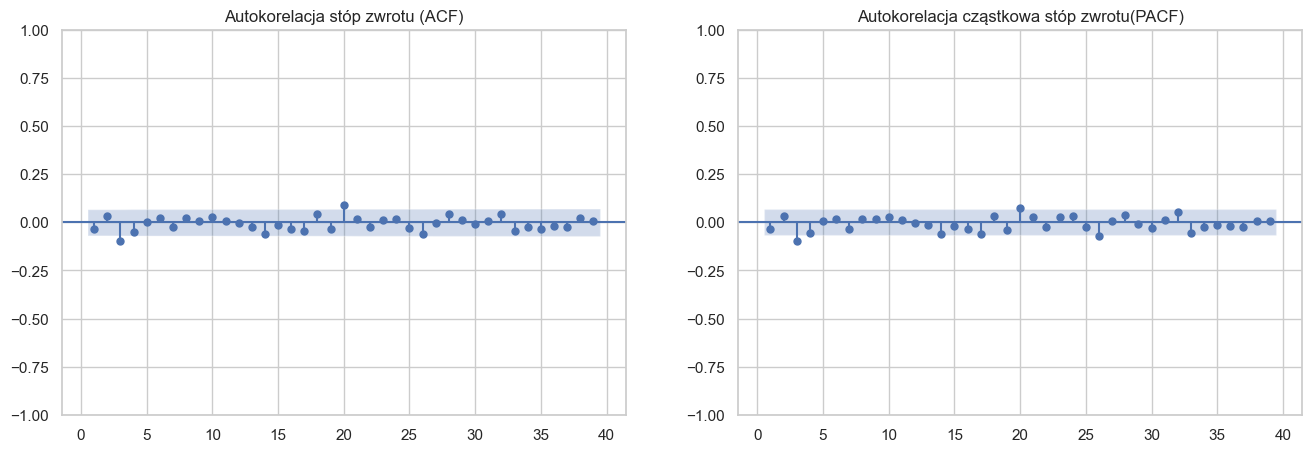

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(df['returns'], lags=range(1, 40), ax=ax1)
ax1.set_title('Autokorelacja stóp zwrotu (ACF)')

plot_pacf(df['returns'], lags= range(1, 40), ax=ax2)
ax2.set_title('Autokorelacja cząstkowa stóp zwrotu(PACF)')

plt.show()

### Test Jarque-Bera na normalność rozkładu stóp zwrotu ###

In [15]:
def check_normality(series):
    jb_stat, jb_p = stats.jarque_bera(series.dropna())
    skewness = series.skew()
    kurtosis = series.kurtosis()
    
    print(f"Test Jarque-Bera p-value: {jb_p:.4f}")
    print(f"Skośność (Skewness): {skewness:.2f}")
    print(f"Kurtoza (Kurtosis): {kurtosis:.2f}")
    
    if jb_p < 0.05:
        print("✅ Rozkład NIE JEST normalny.")
    else:
        print("❌ Rozkład wygląda na normalny.")

check_normality(df['returns'])

Test Jarque-Bera p-value: 0.0000
Skośność (Skewness): 0.32
Kurtoza (Kurtosis): 13.25
✅ Rozkład NIE JEST normalny.


### Histogram zwrotow ###


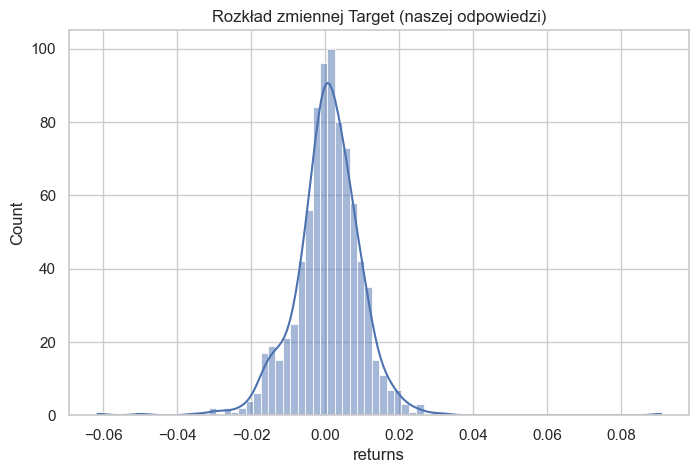

In [20]:
plt.figure(figsize=(8, 5))
sns.histplot(df['returns'], kde=True)
plt.title('Rozkład zmiennej Target (naszej odpowiedzi)')
plt.show()

### Heatmapa poszczególnych dni i miesięcy ###

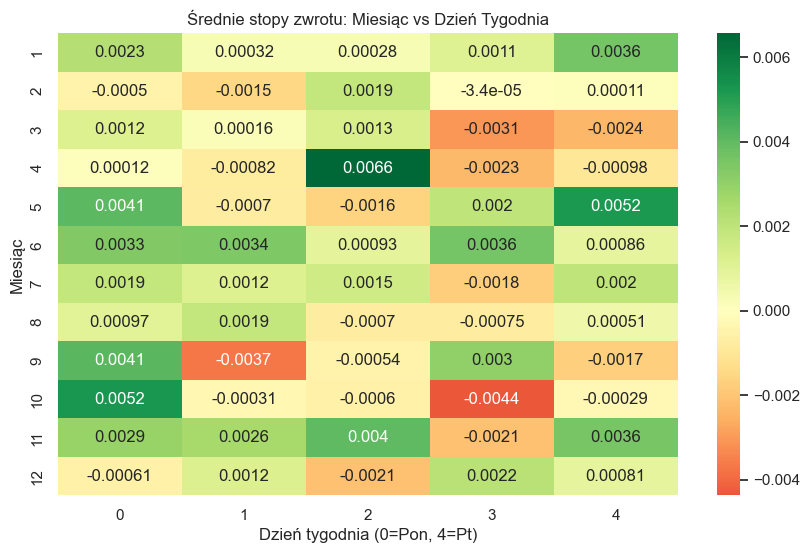

In [16]:
# Przygotowanie danych pod mapę ciepła
df_heat = df.copy()
df_heat['Month'] = df_heat.index.month
df_heat['Weekday'] = df_heat.index.weekday # 0 = Poniedziałek

pivot_table = df_heat.pivot_table(values='returns', index='Month', columns='Weekday', aggfunc='mean')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, cmap='RdYlGn', center=0)
plt.title('Średnie stopy zwrotu: Miesiąc vs Dzień Tygodnia')
plt.xlabel('Dzień tygodnia (0=Pon, 4=Pt)')
plt.ylabel('Miesiąc')
plt.show()

## 4. Zapisanie danych przetransformowanych (dane numeryczne, indeksowane itp.) ##

In [18]:

output_dir = Path("../data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

# Zapisujemy wyczyszczone dane z dodatkowymi kolumnami (returns, volatility)
processed_path = output_dir / "sp500_clean.csv"
df.to_csv(processed_path)

print(f"🚀 Dane gotowe do modelowania zapisane w: {processed_path}")

🚀 Dane gotowe do modelowania zapisane w: ..\data\processed\sp500_clean.csv
